In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [2]:
df=pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape


(42000, 785)

In [5]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
12160,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
import matplotlib.pyplot as plt

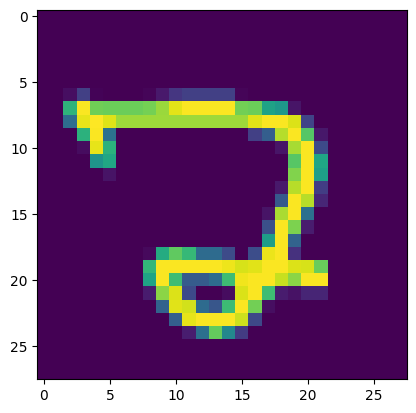

In [7]:
plt.imshow(df.iloc[12160,1:].values.reshape(28,28))

# Train-Test Split

In [8]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
X_train.shape

(33600, 784)

# Finding Accuracy without PCA performed

In [11]:
from sklearn.neighbors import KNeighborsClassifier

In [13]:
knn=KNeighborsClassifier()

In [14]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [16]:
import time
start=time.time()
y_pred=knn.predict(X_test)
print(time.time()-start)

13.325348854064941


In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

# Finding accuracy after pca performed with 100 dimension

In [26]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [27]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [28]:
#pca
from sklearn.decomposition import PCA
pca=PCA(n_components=100)

In [29]:
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [31]:
X_train_trf.shape

(33600, 100)

In [32]:
knn=KNeighborsClassifier()

In [33]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [34]:
y_pred=knn.predict(X_test_trf)

In [35]:
accuracy_score(y_test,y_pred)

0.954047619047619

In [ ]:
for i in range(1,785):
    pca=PCA(n_components=i)
    X_train_trf=pca.fit_transform(X_train)
    X_test_trf=pca.transform(X_test)
    
    knn=KNeighborsClassifier()

    knn.fit(X_train_trf,y_train)

    y_pred=knn.predict(X_test_trf)

    print(accuracy_score(y_test,y_pred))

# 2D visualization

In [37]:
# transforming to a 2D co-ordinate system
pca=PCA(n_components=2)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [41]:
X_train_trf

array([[-2.71862198, -0.4897337 ],
       [-0.6769749 , -6.75381489],
       [-3.03324155,  6.50977139],
       ...,
       [ 2.14884576,  0.78080065],
       [ 1.05958763,  0.9481099 ],
       [17.70257504,  1.96232692]])

In [40]:
import plotly.express as px
y_train_trf=y_train.astype(str)
fig=px.scatter(x=X_train_trf[:,0],
               y=X_train_trf[:,1],
               color=y_train_trf,
               color_discrete_sequence=px.colors.qualitative.G10
              )
fig.show()

# 3D Visualization

In [42]:
# tarnsforming in 3D
pca=PCA(n_components=3)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)


In [43]:
X_train_trf

array([[-2.71865093, -0.4900768 ,  1.13682543],
       [-0.67702612, -6.75348637, -2.33490056],
       [-3.03321588,  6.50965422,  7.49163558],
       ...,
       [ 2.14881125,  0.78066466, -0.74750139],
       [ 1.05957491,  0.94770805,  3.95004147],
       [17.70260569,  1.96247846, -4.94516234]])

In [44]:
y_train_trf=y_train.astype(str)
fig=px.scatter_3d(df,x=X_train_trf[:,0],y=X_train_trf[:,1],z=X_train_trf[:,2],color=y_train_trf)
fig.update_layout(
    margin=dict(l=20,r=20,t=20,b=20)
)
fig.show()

In [47]:
#Eigen Values
pca.explained_variance_


array([40.67111198, 29.17023393, 26.74459516])

In [50]:
#Eigen vectors
pca.components_.shape

(3, 784)

In [52]:
#Eigen values with percentage varience  
pca.explained_variance_ratio_


array([0.05785192, 0.0414927 , 0.03804239])

# To find the perfect eigen values that shows varience percentage from a original dataset

In [53]:
pca=PCA(n_components=None)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [55]:
pca.explained_variance_.shape

(784,)

In [58]:
pca.components_.shape

(784, 784)

In [61]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

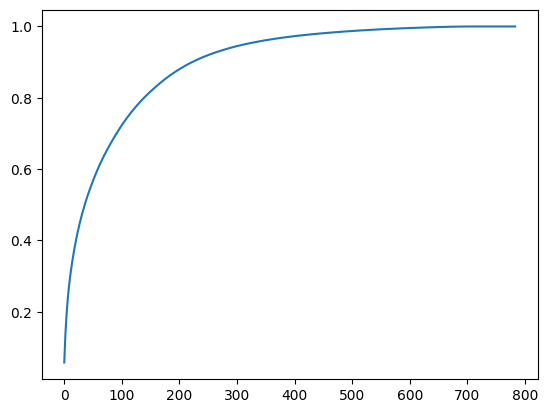

In [62]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))